# 4.1.1 : Hill Climbing for 8-Queens

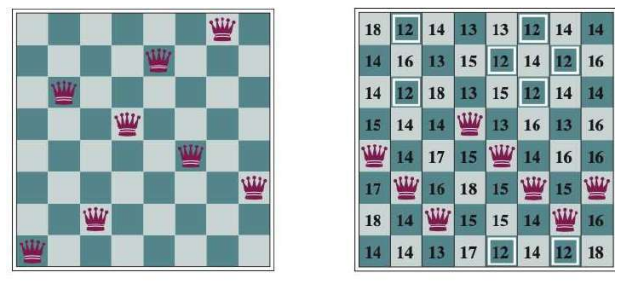

Problem: Place 8 queens on a chessboard so that no two queens attack each other.

State Representation:

Each state is a full board (8 queens, one per column).

Example: [0, 4, 7, 5, 2, 6, 1, 3] → each index is a column, value is the row.

Heuristic (h):

h(state) = number of pairs of queens attacking each other

Goal: h = 0 → no attacks.

In [1]:
import random

N = 8  # Number of queens

# Heuristic function: count of attacking pairs
def VALUE(state):
    attacks = 0
    for i in range(N):
        for j in range(i+1, N):
            if state[i] == state[j] or abs(state[i] - state[j]) == j - i:
                attacks += 1
    return -attacks  # Since hill climbing maximizes value, we use negative attacks

# Generate all neighbors by moving one queen in its column
def get_successors(state):
    successors = []
    for col in range(N):
        for row in range(N):
            if row != state[col]:
                new_state = state.copy()
                new_state[col] = row
                successors.append(new_state)
    return successors

# Hill Climbing Algorithm
def HILL_CLIMBING(problem):
    current = problem['INITIAL']
    
    while True:
        neighbors = get_successors(current)
        # Find neighbor with highest value
        neighbor = max(neighbors, key=VALUE)
        
        if VALUE(neighbor) <= VALUE(current):
            return current  # local maximum reached
        current = neighbor

# Random initial state
initial_state = [random.randint(0, N-1) for _ in range(N)]
problem = {'INITIAL': initial_state}

solution = HILL_CLIMBING(problem)
print("Initial state:", initial_state)
print("Final state:", solution)
print("Heuristic value (attacking pairs):", -VALUE(solution))


Initial state: [3, 7, 3, 2, 7, 2, 2, 5]
Final state: [4, 1, 3, 5, 7, 2, 0, 6]
Heuristic value (attacking pairs): 0
